# Graduate Employment Status — Classification

This notebook predicts **Employment_Status** using three classes:

- Employed
- Continuing Education
- Unemployed

The workflow is kept simple and ordered: data check → feature analysis → feature engineering → split → preprocessing → models → tuning → final evaluation → interpretation.

### Notebook cleanup notes

This version removes empty/repeated cells, keeps one evaluation function, uses the validation set for model selection, and keeps only useful plots.

## 1. Project Scope

**Target:** `Employment_Status`

**Features used for classification:** academic, language, visa, university, demographic, and internship information.

**Excluded from classification:**
- `Salary` — used later for salary regression and can reveal employment status.
- `Job_Sector` — describes the job sector and has many missing values for graduates without a job.

**Main evaluation metric:** `Macro F1`, because all three classes should receive equal importance.

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [2]:
# Load the dataset
df = pd.read_csv("dataset.csv")

print("Dataset shape:", df.shape)

Dataset shape: (300000, 15)


## 2. Data Understanding

First, check the structure, data types, and missing values.

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

Columns:
['Country_of_Origin', 'Education_Level', 'Field_of_Study', 'Language_Proficiency', 'Visa_Type', 'Gender', 'University_Ranking', 'Region_of_Study', 'Age', 'Years_Since_Graduation', 'GPA', 'Internship_Experience', 'Employment_Status', 'Salary', 'Job_Sector']

Data types:
Country_of_Origin          object
Education_Level            object
Field_of_Study             object
Language_Proficiency       object
Visa_Type                  object
Gender                     object
University_Ranking         object
Region_of_Study            object
Age                         int64
Years_Since_Graduation      int64
GPA                       float64
Internship_Experience      object
Employment_Status          object
Salary                      int64
Job_Sector                 object
dtype: object

Missing values:


Job_Sector                143356
Education_Level                0
Country_of_Origin              0
Language_Proficiency           0
Visa_Type                      0
Gender                         0
Field_of_Study                 0
University_Ranking             0
Region_of_Study                0
Years_Since_Graduation         0
Age                            0
GPA                            0
Internship_Experience          0
Employment_Status              0
Salary                         0
dtype: int64

In [4]:
# Check duplicate rows and target distribution
print("Duplicate rows:", df.duplicated().sum())

print("\nEmployment Status distribution:")
target_distribution = pd.DataFrame({
    "Count": df["Employment_Status"].value_counts(),
    "Percentage": (
        df["Employment_Status"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(target_distribution)

Duplicate rows: 3

Employment Status distribution:


,Count,Percentage
Employment_Status,,
Employed,156644,52.21
Continuing Education,74617,24.87
Unemployed,68739,22.91


In [5]:
# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print(f"Rows removed: {before - after}")
print("New shape:", df.shape)

Rows removed: 3
New shape: (299997, 15)


### Data quality decision

`Age` and `Years_Since_Graduation` are within reasonable ranges.
`GPA` includes values above 4, and these values are treated as valid data in this project, so no GPA values are changed or removed.

In [6]:
# Check numerical ranges
print("Age:", df["Age"].min(), "to", df["Age"].max())
print("Years_Since_Graduation:", df["Years_Since_Graduation"].min(), "to", df["Years_Since_Graduation"].max())
print("GPA:", df["GPA"].min(), "to", df["GPA"].max())
print("GPA values > 4:", (df["GPA"] > 4).sum())
print("Salary:", df["Salary"].min(), "to", df["Salary"].max())

Age: 22 to 39
Years_Since_Graduation: 0 to 9
GPA: 1.35 to 4.92
GPA values > 4: 6554
Salary: 0 to 118115


## 3. Exploratory Analysis

The following plots focus on variables that showed clear differences between the three employment outcomes.

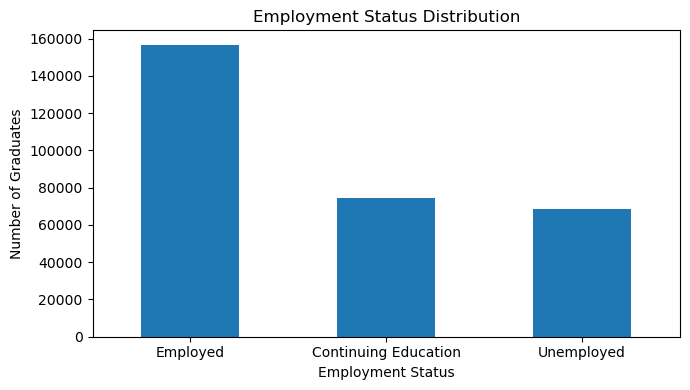

In [7]:
# Target distribution
counts = df["Employment_Status"].value_counts()

plt.figure(figsize=(7, 4))
counts.plot(kind="bar")
plt.title("Employment Status Distribution")
plt.xlabel("Employment Status")
plt.ylabel("Number of Graduates")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

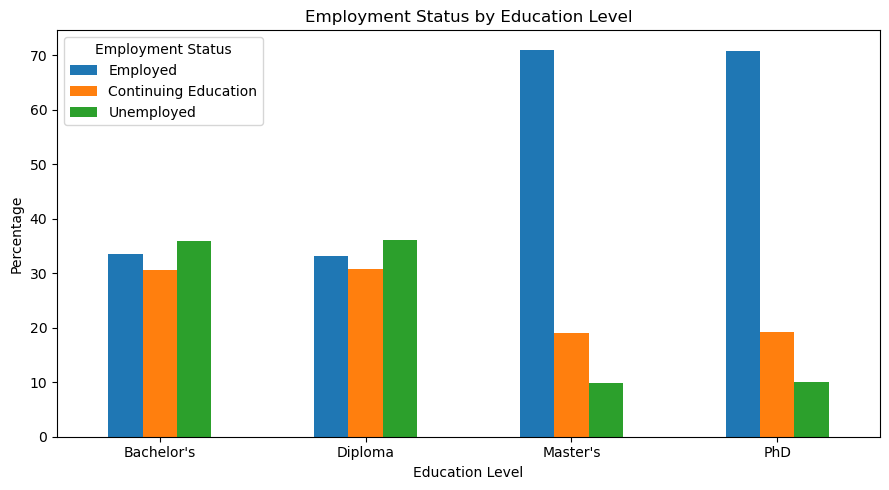

In [8]:
# Employment rate by education level
education_rate = pd.crosstab(
    df["Education_Level"],
    df["Employment_Status"],
    normalize="index"
).mul(100)

education_rate[["Employed", "Continuing Education", "Unemployed"]].plot(
    kind="bar", figsize=(9, 5)
)
plt.title("Employment Status by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Employment Status")
plt.tight_layout()
plt.show()

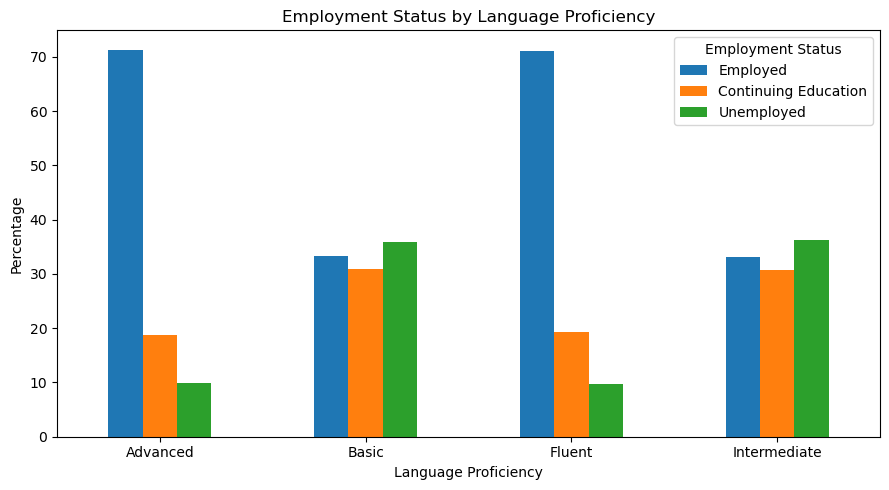

In [9]:
# Employment rate by language proficiency
language_rate = pd.crosstab(
    df["Language_Proficiency"],
    df["Employment_Status"],
    normalize="index"
).mul(100)

language_rate[["Employed", "Continuing Education", "Unemployed"]].plot(
    kind="bar", figsize=(9, 5)
)
plt.title("Employment Status by Language Proficiency")
plt.xlabel("Language Proficiency")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Employment Status")
plt.tight_layout()
plt.show()

In [10]:
# Numerical features by employment status
numerical_features_check = ["Age", "Years_Since_Graduation", "GPA"]

for col in numerical_features_check:
    print(f"\n{col}")
    display(
        df.groupby("Employment_Status")[col]
        .agg(["mean", "median", "std"])
        .round(3)
    )


Age


,mean,median,std
Employment_Status,,,
Continuing Education,30.483,30.0,5.180
Employed,30.484,30.0,5.191
Unemployed,30.537,31.0,5.190



Years_Since_Graduation


,mean,median,std
Employment_Status,,,
Continuing Education,4.822,5.0,2.789
Employed,4.084,4.0,2.937
Unemployed,5.117,5.0,2.660



GPA


,mean,median,std
Employment_Status,,,
Continuing Education,3.136,3.15,0.370
Employed,3.279,3.29,0.422
Unemployed,3.091,3.11,0.339


## 4. Feature Interaction Analysis

Some combinations are more informative than individual variables. The strongest patterns were found in education, language, and internship/university combinations.

In [11]:
interaction_pairs = [
    ("Education_Level", "Language_Proficiency"),
    ("Education_Level", "Internship_Experience"),
    ("University_Ranking", "Internship_Experience")
]

for col1, col2 in interaction_pairs:
    print(f"\n{col1} × {col2}")
    table = pd.crosstab(
        [df[col1], df[col2]],
        df["Employment_Status"],
        normalize="index"
    ).mul(100).round(1)
    display(table)


Education_Level × Language_Proficiency


Employment_Status                     Continuing Education  Employed  \
Education_Level Language_Proficiency                                   
Bachelor's      Advanced                              27.7      52.5   
                Basic                                 33.4      15.0   
                Fluent                                28.4      52.1   
                Intermediate                          32.9      14.8   
Diploma         Advanced                              28.0      52.2   
                Basic                                 33.5      14.2   
                Fluent                                29.2      51.9   
                Intermediate                          32.8      14.6   
Master's        Advanced                              10.1      89.9   
                Basic                                 28.2      52.2   
                Fluent                                 9.8      90.2   
                Intermediate                          28.3      51.6   
PhD             Advanced                               9.9      90.1   
                Basic                                 28.2      51.3   
                Fluent                                10.0      90.0   
                Intermediate                          28.7      51.7   

Employment_Status                     Unemployed  
Education_Level Language_Proficiency              
Bachelor's      Advanced                    19.8  
                Basic                       51.5  
                Fluent                      19.5  
                Intermediate                52.2  
Diploma         Advanced                    19.8  
                Basic                       52.3  
                Fluent                      18.9  
                Intermediate                52.6  
Master's        Advanced                     0.0  
                Basic                       19.6  
                Fluent                       0.0  
                Intermediate                20.1  
PhD             Advanced                     0.0  
                Basic                       20.5  
                Fluent                       0.0  
                Intermediate                19.7


Education_Level × Internship_Experience


Employment_Status                      Continuing Education  Employed  \
Education_Level Internship_Experience                                   
Bachelor's      No                                     32.7      22.8   
                Yes                                    29.4      39.4   
Diploma         No                                     33.3      22.0   
                Yes                                    29.5      39.2   
Master's        No                                     23.6      62.3   
                Yes                                    16.6      75.7   
PhD             No                                     24.8      61.0   
                Yes                                    16.2      76.1   

Employment_Status                      Unemployed  
Education_Level Internship_Experience              
Bachelor's      No                           44.5  
                Yes                          31.2  
Diploma         No                           44.7  
                Yes                          31.3  
Master's        No                           14.1  
                Yes                           7.6  
PhD             No                           14.1  
                Yes                           7.8


University_Ranking × Internship_Experience


Employment_Status                         Continuing Education  Employed  \
University_Ranking Internship_Experience                                   
High               No                                     25.4      50.2   
                   Yes                                    16.6      75.4   
Low                No                                     29.8      38.4   
                   Yes                                    25.5      50.1   
Medium             No                                     29.7      39.0   
                   Yes                                    25.8      49.8   

Employment_Status                         Unemployed  
University_Ranking Internship_Experience              
High               No                           24.4  
                   Yes                           8.0  
Low                No                           31.9  
                   Yes                          24.4  
Medium             No                           31.3  
                   Yes                          24.4

In [12]:
# Create a small number of meaningful interaction features
# These combine categories that showed clear patterns in the EDA.
df["Education_Language"] = (
    df["Education_Level"] + "_" + df["Language_Proficiency"]
)

df["Education_Internship"] = (
    df["Education_Level"] + "_" + df["Internship_Experience"]
)

df["University_Internship"] = (
    df["University_Ranking"] + "_" + df["Internship_Experience"]
)

print("Interaction features created:")
print([
    "Education_Language",
    "Education_Internship",
    "University_Internship"
])

Interaction features created:
['Education_Language', 'Education_Internship', 'University_Internship']


## 5. Prepare the Classification Data

We keep the original 12 useful features and add the 3 interaction features above.

In [13]:
classification_features = [
    "Country_of_Origin",
    "Education_Level",
    "Field_of_Study",
    "Language_Proficiency",
    "Visa_Type",
    "Gender",
    "University_Ranking",
    "Region_of_Study",
    "Age",
    "Years_Since_Graduation",
    "GPA",
    "Internship_Experience",
    "Education_Language",
    "Education_Internship",
    "University_Internship"
]

target = "Employment_Status"

X = df[classification_features]
y = df[target]

print("Features:", X.shape[1])
print("Rows:", X.shape[0])

Features: 15
Rows: 299997


## 6. Train / Validation / Test Split

- 80% Train
- 10% Validation
- 10% Test

`stratify=y` keeps the class proportions similar in all three sets.

In [14]:
# 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split temporary data into 10% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (239997, 15)
Validation: (30000, 15)
Test: (30000, 15)


## 7. Preprocessing

Categorical features are converted with One-Hot Encoding.
Numerical features are scaled with StandardScaler.

The preprocessor is fitted **only on the training data**.

In [15]:
categorical_features = [
    "Country_of_Origin",
    "Education_Level",
    "Field_of_Study",
    "Language_Proficiency",
    "Visa_Type",
    "Gender",
    "University_Ranking",
    "Region_of_Study",
    "Internship_Experience",
    "Education_Language",
    "Education_Internship",
    "University_Internship"
]

numerical_features = [
    "Age",
    "Years_Since_Graduation",
    "GPA"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed train:", X_train_processed.shape)
print("Processed validation:", X_val_processed.shape)
print("Processed test:", X_test_processed.shape)

Processed train: (239997, 71)
Processed validation: (30000, 71)
Processed test: (30000, 71)


## 8. Simple Baseline

The DummyClassifier always predicts the most common class. Real models should clearly beat this baseline.

In [16]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train_processed, y_train)
y_val_pred_dummy = dummy_model.predict(X_val_processed)

print("Dummy Classifier")
print("Accuracy:", round(accuracy_score(y_val, y_val_pred_dummy), 4))
print("Macro F1:", round(f1_score(y_val, y_val_pred_dummy, average="macro"), 4))

Dummy Classifier
Accuracy: 0.5222
Macro F1: 0.2287


## 9. Model Evaluation Helper

In [17]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro_Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

# 10. Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

logreg_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_baseline.fit(X_train_processed, y_train)
y_val_pred_logreg = logreg_baseline.predict(X_val_processed)

logreg_baseline_results = evaluate_model(
    "Logistic Regression - Baseline",
    y_val,
    y_val_pred_logreg
)

print(pd.DataFrame([logreg_baseline_results]).round(4))

                            Model  Accuracy  Macro_Precision  Macro_Recall  \
0  Logistic Regression - Baseline    0.6474           0.5575        0.5583   

   Macro_F1  
0    0.5467  


### Logistic Regression tuning

We tune `C` and `class_weight` and choose the setting with the highest **Macro F1** on the validation set.

In [19]:
C_values = [0.01, 0.1, 1, 10, 100]
class_weights = [None, "balanced"]

logreg_tuning = []

for C in C_values:
    for class_weight in class_weights:
        model = LogisticRegression(
            C=C,
            class_weight=class_weight,
            max_iter=2000,
            solver="lbfgs",
            random_state=42
        )
        model.fit(X_train_processed, y_train)
        pred = model.predict(X_val_processed)
        row = evaluate_model("Logistic Regression", y_val, pred)
        row.update({"C": C, "class_weight": class_weight})
        logreg_tuning.append(row)

logreg_tuning_df = pd.DataFrame(logreg_tuning).sort_values("Macro_F1", ascending=False)
display(logreg_tuning_df.round(4))

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,C,class_weight
1,Logistic Regression,0.6303,0.5766,0.5841,0.5782,0.01,balanced
7,Logistic Regression,0.6301,0.5762,0.5846,0.5781,10.00,balanced
9,Logistic Regression,0.6301,0.5759,0.5843,0.5778,100.00,balanced
3,Logistic Regression,0.6300,0.5759,0.5841,0.5777,0.10,balanced
5,Logistic Regression,0.6298,0.5757,0.5840,0.5776,1.00,balanced
8,Logistic Regression,0.6476,0.5581,0.5587,0.5472,100.00,None
6,Logistic Regression,0.6475,0.5579,0.5586,0.5471,10.00,None
2,Logistic Regression,0.6474,0.5579,0.5583,0.5470,0.10,None
4,Logistic Regression,0.6474,0.5575,0.5583,0.5467,1.00,None
0,Logistic Regression,0.6473,0.5579,0.5577,0.5467,0.01,None


In [20]:
# Select the best Logistic Regression settings from validation results
best_logreg_row = logreg_tuning_df.iloc[0]

best_logreg = LogisticRegression(
    C=float(best_logreg_row["C"]),
    class_weight=best_logreg_row["class_weight"],
    max_iter=2000,
    solver="lbfgs",
    random_state=42
)

best_logreg.fit(X_train_processed, y_train)
y_val_pred_best_logreg = best_logreg.predict(X_val_processed)

print("Selected parameters:")
print("C:", best_logreg_row["C"])
print("class_weight:", best_logreg_row["class_weight"])
print()
print(classification_report(y_val, y_val_pred_best_logreg, zero_division=0))

Selected parameters:
C: 0.01
class_weight: balanced

                      precision    recall  f1-score   support

Continuing Education       0.35      0.38      0.36      7461
            Employed       0.85      0.76      0.80     15665
          Unemployed       0.53      0.62      0.57      6874

            accuracy                           0.63     30000
           macro avg       0.58      0.58      0.58     30000
        weighted avg       0.65      0.63      0.64     30000



# 11. Decision Tree

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train_processed, y_train)
y_val_pred_dt_baseline = dt_baseline.predict(X_val_processed)

print(pd.DataFrame([
    evaluate_model("Decision Tree - Baseline", y_val, y_val_pred_dt_baseline)
]).round(4))

                      Model  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
0  Decision Tree - Baseline    0.6015           0.5379        0.5355    0.5366


In [22]:
# Light hyperparameter tuning for Decision Tree
DT_PARAMS = [
    {"max_depth": 5,  "min_samples_leaf": 10, "min_samples_split": 20, "class_weight": None},
    {"max_depth": 8,  "min_samples_leaf": 10, "min_samples_split": 20, "class_weight": None},
    {"max_depth": 10, "min_samples_leaf": 10, "min_samples_split": 20, "class_weight": None},
    {"max_depth": 12, "min_samples_leaf": 10, "min_samples_split": 20, "class_weight": None},
    {"max_depth": 15, "min_samples_leaf": 10, "min_samples_split": 20, "class_weight": None},
    {"max_depth": 8,  "min_samples_leaf": 10, "min_samples_split": 20, "class_weight": "balanced"},
    {"max_depth": 10, "min_samples_leaf": 10, "min_samples_split": 20, "class_weight": "balanced"},
    {"max_depth": 12, "min_samples_leaf": 10, "min_samples_split": 20, "class_weight": "balanced"},
    {"max_depth": 10, "min_samples_leaf": 20, "min_samples_split": 50, "class_weight": None},
    {"max_depth": 12, "min_samples_leaf": 20, "min_samples_split": 50, "class_weight": None},
]

dt_tuning = []

for params in DT_PARAMS:
    model = DecisionTreeClassifier(random_state=42, **params)
    model.fit(X_train_processed, y_train)
    pred = model.predict(X_val_processed)
    row = evaluate_model("Decision Tree", y_val, pred)
    row.update(params)
    dt_tuning.append(row)

dt_tuning_df = pd.DataFrame(dt_tuning).sort_values("Macro_F1", ascending=False)
display(dt_tuning_df.round(4))

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,max_depth,min_samples_leaf,min_samples_split,class_weight
9,Decision Tree,0.6773,0.5902,0.6079,0.5906,12,20,50,None
3,Decision Tree,0.6771,0.5896,0.6103,0.5882,12,10,20,None
4,Decision Tree,0.6682,0.5834,0.6003,0.5854,15,10,20,None
1,Decision Tree,0.6785,0.5876,0.6106,0.5846,8,10,20,None
8,Decision Tree,0.6811,0.5902,0.6152,0.5818,10,20,50,None
2,Decision Tree,0.6797,0.5869,0.6142,0.5766,10,10,20,None
0,Decision Tree,0.6404,0.5432,0.5661,0.5352,5,10,20,None
7,Decision Tree,0.6726,0.5588,0.6162,0.5325,12,10,20,balanced
6,Decision Tree,0.6743,0.5602,0.6179,0.5279,10,10,20,balanced
5,Decision Tree,0.6741,0.5704,0.6100,0.5225,8,10,20,balanced


In [23]:
# Best Decision Tree from validation tuning
best_dt = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=20,
    min_samples_split=50,
    class_weight=None,
    random_state=42
)

best_dt.fit(X_train_processed, y_train)
y_val_pred_best_dt = best_dt.predict(X_val_processed)

print(classification_report(
    y_val,
    y_val_pred_best_dt,
    zero_division=0
))

                      precision    recall  f1-score   support

Continuing Education       0.39      0.26      0.31      7461
            Employed       0.86      0.87      0.86     15665
          Unemployed       0.52      0.69      0.59      6874

            accuracy                           0.68     30000
           macro avg       0.59      0.61      0.59     30000
        weighted avg       0.66      0.68      0.66     30000



# 12. Random Forest

Random Forest tuning was skipped in the working notebook to reduce runtime and memory use. We keep the baseline model for comparison.

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train)
y_val_pred_rf = rf_model.predict(X_val_processed)

print(pd.DataFrame([
    evaluate_model("Random Forest - Baseline", y_val, y_val_pred_rf)
]).round(4))

                      Model  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
0  Random Forest - Baseline    0.6717           0.5855        0.5978    0.5866


# 13. Gaussian Naive Bayes

We tune `var_smoothing`. This model is kept for comparison even though its performance is much lower than the tree-based models.

In [25]:
from sklearn.naive_bayes import GaussianNB

X_train_dense = X_train_processed.toarray()
X_val_dense = X_val_processed.toarray()
X_test_dense = X_test_processed.toarray()

var_values = [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
nb_tuning = []

for var in var_values:
    model = GaussianNB(var_smoothing=var)
    model.fit(X_train_dense, y_train)
    pred = model.predict(X_val_dense)
    row = evaluate_model("Gaussian Naive Bayes", y_val, pred)
    row["var_smoothing"] = var
    nb_tuning.append(row)

nb_tuning_df = pd.DataFrame(nb_tuning).sort_values("Macro_F1", ascending=False)
display(nb_tuning_df.round(4))

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,var_smoothing
7,Gaussian Naive Bayes,0.5003,0.3935,0.5005,0.3826,0.0
6,Gaussian Naive Bayes,0.4718,0.4037,0.4883,0.3635,0.0
5,Gaussian Naive Bayes,0.4711,0.4035,0.4878,0.3629,0.0
4,Gaussian Naive Bayes,0.4589,0.4027,0.4800,0.3539,0.0
3,Gaussian Naive Bayes,0.4587,0.4026,0.4799,0.3537,0.0
2,Gaussian Naive Bayes,0.4587,0.4026,0.4799,0.3537,0.0
1,Gaussian Naive Bayes,0.4587,0.4026,0.4799,0.3537,0.0
0,Gaussian Naive Bayes,0.4587,0.4026,0.4799,0.3537,0.0


In [26]:
# Select the best Naive Bayes setting from validation results
best_nb_row = nb_tuning_df.iloc[0]
best_nb = GaussianNB(var_smoothing=float(best_nb_row["var_smoothing"]))
best_nb.fit(X_train_dense, y_train)
y_val_pred_nb = best_nb.predict(X_val_dense)

print("Selected var_smoothing:", best_nb_row["var_smoothing"])
print(pd.DataFrame([
    evaluate_model("Gaussian Naive Bayes", y_val, y_val_pred_nb)
]).round(4))

Selected var_smoothing: 1e-05
                  Model  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
0  Gaussian Naive Bayes    0.5003           0.3935        0.5005    0.3826


# 14. K-Nearest Neighbors

KNN is expensive on very large training sets, so a stratified 50,000-row training sample is used for the KNN comparison.

In [27]:
from sklearn.neighbors import KNeighborsClassifier

X_train_knn, _, y_train_knn, _ = train_test_split(
    X_train_processed,
    y_train,
    train_size=50000,
    random_state=42,
    stratify=y_train
)

knn_baseline = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    n_jobs=-1
)
knn_baseline.fit(X_train_knn, y_train_knn)
y_val_pred_knn_baseline = knn_baseline.predict(X_val_processed)

print(pd.DataFrame([
    evaluate_model("KNN - Baseline", y_val, y_val_pred_knn_baseline)
]).round(4))

            Model  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
0  KNN - Baseline    0.6135           0.5443        0.5366    0.5395


In [28]:
# Light KNN tuning
KNN_PARAMS = [
    # {"n_neighbors": 3, "weights": "uniform", "metric": "euclidean"},
    # {"n_neighbors": 5, "weights": "uniform", "metric": "euclidean"},
    # {"n_neighbors": 7, "weights": "uniform", "metric": "euclidean"},
    # {"n_neighbors": 9, "weights": "uniform", "metric": "euclidean"},
    # {"n_neighbors": 5, "weights": "distance", "metric": "euclidean"},
    # {"n_neighbors": 7, "weights": "distance", "metric": "euclidean"},
    {"n_neighbors": 9, "weights": "distance", "metric": "euclidean"},
    # {"n_neighbors": 5, "weights": "distance", "metric": "manhattan"},
    # {"n_neighbors": 7, "weights": "distance", "metric": "manhattan"},
]

knn_tuning = []

for params in KNN_PARAMS:
    model = KNeighborsClassifier(**params, n_jobs=-1)
    model.fit(X_train_knn, y_train_knn)
    pred = model.predict(X_val_processed)
    row = evaluate_model("KNN", y_val, pred)
    row.update(params)
    knn_tuning.append(row)

knn_tuning_df = pd.DataFrame(knn_tuning).sort_values("Macro_F1", ascending=False)
display(knn_tuning_df.round(4))

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,n_neighbors,weights,metric
0,KNN,0.6364,0.5498,0.5582,0.5496,9,distance,euclidean


# 15. HistGradientBoosting

HistGradientBoosting is used as a faster gradient boosting option for this large dataset. Tuning was skipped to save runtime.

In [30]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(random_state=42)
hgb_model.fit(X_train_dense, y_train)
y_val_pred_hgb = hgb_model.predict(X_val_dense)

print(pd.DataFrame([
    evaluate_model("HistGradientBoosting", y_val, y_val_pred_hgb)
]).round(4))

                  Model  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
0  HistGradientBoosting    0.6813           0.5938        0.6138    0.5927


# 16. Linear SVM

A linear SVM is used because a full RBF SVM would be too expensive for this dataset size. No tuning was applied in the working notebook.

In [31]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)
svm_model.fit(X_train_processed, y_train)
y_val_pred_svm = svm_model.predict(X_val_processed)

print(pd.DataFrame([
    evaluate_model("Linear SVM", y_val, y_val_pred_svm)
]).round(4))

        Model  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
0  Linear SVM    0.6426           0.5402        0.5418    0.4883


# 17. Validation Model Comparison

In [32]:
validation_predictions = {
    "Logistic Regression": y_val_pred_best_logreg,
    "Decision Tree": y_val_pred_best_dt,
    "Random Forest": y_val_pred_rf,
    "Gaussian Naive Bayes": y_val_pred_nb,
    "KNN": y_val_pred_knn,
    "HistGradientBoosting": y_val_pred_hgb,
    "Linear SVM": y_val_pred_svm
}

validation_results = pd.DataFrame([
    evaluate_model(name, y_val, pred)
    for name, pred in validation_predictions.items()
]).sort_values("Macro_F1", ascending=False)

display(validation_results.round(4))

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
5,HistGradientBoosting,0.6813,0.5938,0.6138,0.5927
1,Decision Tree,0.6773,0.5902,0.6079,0.5906
2,Random Forest,0.6717,0.5855,0.5978,0.5866
0,Logistic Regression,0.6303,0.5766,0.5841,0.5782
4,KNN,0.6364,0.5498,0.5582,0.5496
6,Linear SVM,0.6426,0.5402,0.5418,0.4883
3,Gaussian Naive Bayes,0.5003,0.3935,0.5005,0.3826


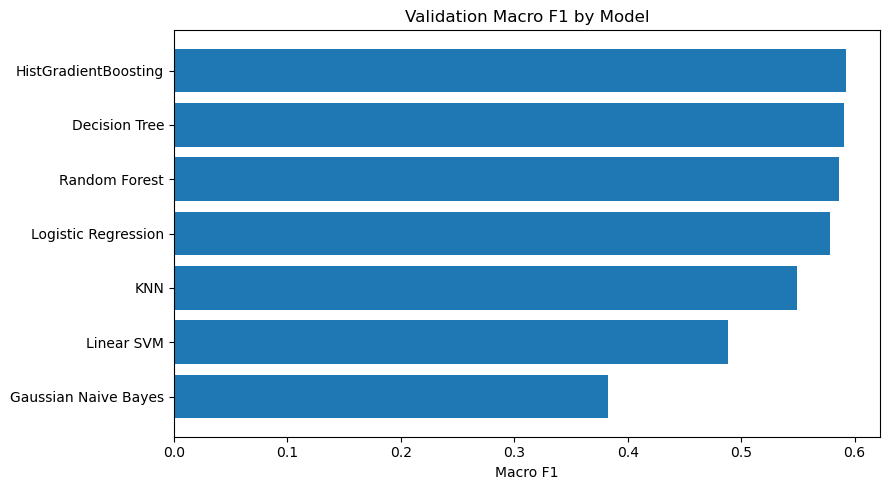

In [33]:
# Visual comparison of Macro F1 on validation data
plt.figure(figsize=(9, 5))
plot_data = validation_results.sort_values("Macro_F1", ascending=True)
plt.barh(plot_data["Model"], plot_data["Macro_F1"])
plt.title("Validation Macro F1 by Model")
plt.xlabel("Macro F1")
plt.tight_layout()
plt.show()

# 18. Final Test Evaluation

The Test set is now used once to report the final performance of every selected model configuration. It is not used for tuning or selection.

In [34]:
# Test predictions
X_test_dense = X_test_processed.toarray()

test_predictions = {
    "Logistic Regression": best_logreg.predict(X_test_processed),
    "Decision Tree": best_dt.predict(X_test_processed),
    "Random Forest": rf_model.predict(X_test_processed),
    "Gaussian Naive Bayes": best_nb.predict(X_test_dense),
    "KNN": best_knn.predict(X_test_processed),
    "HistGradientBoosting": hgb_model.predict(X_test_dense),
    "Linear SVM": svm_model.predict(X_test_processed)
}

test_results = pd.DataFrame([
    evaluate_model(name, y_test, pred)
    for name, pred in test_predictions.items()
]).sort_values("Macro_F1", ascending=False)

display(test_results.round(4))

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
1,Decision Tree,0.6783,0.5940,0.6121,0.5940
5,HistGradientBoosting,0.6795,0.5924,0.6139,0.5912
2,Random Forest,0.6705,0.5854,0.5980,0.5861
0,Logistic Regression,0.6287,0.5786,0.5861,0.5798
4,KNN,0.6351,0.5502,0.5590,0.5506
6,Linear SVM,0.6432,0.5388,0.5443,0.4907
3,Gaussian Naive Bayes,0.4938,0.3914,0.4955,0.3779


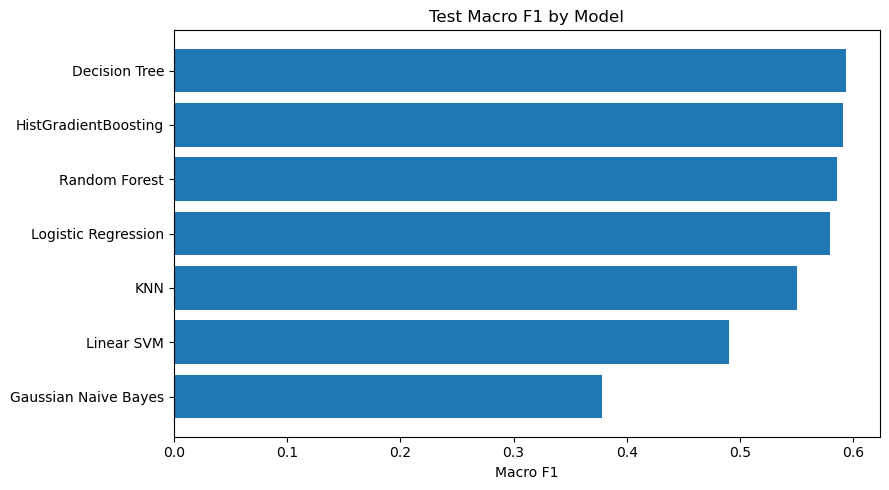

In [35]:
# Test Macro F1 comparison
plt.figure(figsize=(9, 5))
plot_data = test_results.sort_values("Macro_F1", ascending=True)
plt.barh(plot_data["Model"], plot_data["Macro_F1"])
plt.title("Test Macro F1 by Model")
plt.xlabel("Macro F1")
plt.tight_layout()
plt.show()

# 19. Final Model Selection

The final predictive model is selected using **Validation Macro F1**. The Test set is used only after model selection.

In the current run, the validation results place HistGradientBoosting slightly above the Decision Tree. The Decision Tree is still used for feature interpretation because it provides direct feature importance.

Selected final model: HistGradientBoosting

                      precision    recall  f1-score   support

Continuing Education       0.39      0.25      0.30      7462
            Employed       0.86      0.86      0.86     15664
          Unemployed       0.52      0.73      0.61      6874

            accuracy                           0.68     30000
           macro avg       0.59      0.61      0.59     30000
        weighted avg       0.67      0.68      0.67     30000



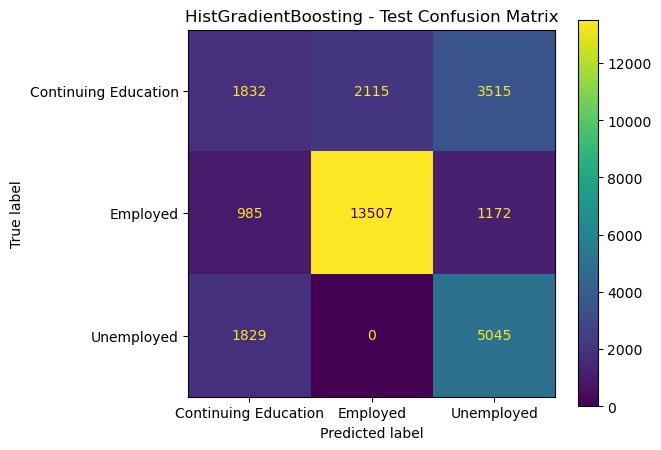

In [36]:
# Select the model with the highest Validation Macro F1
model_objects = {
    "Logistic Regression": best_logreg,
    "Decision Tree": best_dt,
    "Random Forest": rf_model,
    "Gaussian Naive Bayes": best_nb,
    "KNN": best_knn,
    "HistGradientBoosting": hgb_model,
    "Linear SVM": svm_model
}

final_model_name = validation_results.iloc[0]["Model"]
final_model = model_objects[final_model_name]
final_test_pred = test_predictions[final_model_name]

print("Selected final model:", final_model_name)
print()
print(classification_report(y_test, final_test_pred, zero_division=0))

cm = confusion_matrix(y_test, final_test_pred)
labels = final_model.classes_ if hasattr(final_model, "classes_") else sorted(y_test.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title(f"{final_model_name} - Test Confusion Matrix")
plt.tight_layout()
plt.show()

## What the confusion matrix shows

The main difficulty in the current results is separating `Continuing Education` from the other two classes.

# 20. ROC-AUC Analysis

ROC-AUC is calculated as one-vs-rest for the three classes. It shows how well the model ranks the correct class before the final class decision.

In [37]:
# ROC-AUC for the validation-selected model
if hasattr(final_model, "predict_proba"):
    val_matrix = X_val_dense if final_model_name in ["HistGradientBoosting", "Gaussian Naive Bayes"] else X_val_processed
    val_proba = final_model.predict_proba(val_matrix)

    macro_auc = roc_auc_score(y_val, val_proba, multi_class="ovr", average="macro")
    weighted_auc = roc_auc_score(y_val, val_proba, multi_class="ovr", average="weighted")

    print("Selected model:", final_model_name)
    print("Macro ROC-AUC:", round(macro_auc, 4))
    print("Weighted ROC-AUC:", round(weighted_auc, 4))
else:
    print(f"{final_model_name} does not provide predict_proba, so ROC-AUC is skipped.")

Selected model: HistGradientBoosting
Macro ROC-AUC: 0.8255
Weighted ROC-AUC: 0.8451


,Class,ROC_AUC
0,Continuing Education,0.7000
1,Employed,0.9009
2,Unemployed,0.8757


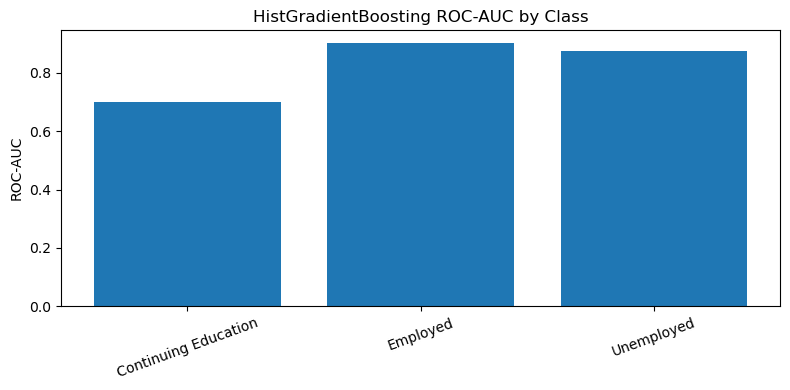

In [38]:
# ROC-AUC for each class
if hasattr(final_model, "predict_proba"):
    class_auc = []
    for i, cls in enumerate(final_model.classes_):
        binary_true = (y_val == cls).astype(int)
        auc = roc_auc_score(binary_true, val_proba[:, i])
        class_auc.append({"Class": cls, "ROC_AUC": auc})

    class_auc_df = pd.DataFrame(class_auc)
    display(class_auc_df.round(4))

    plt.figure(figsize=(8, 4))
    plt.bar(class_auc_df["Class"], class_auc_df["ROC_AUC"])
    plt.title(f"{final_model_name} ROC-AUC by Class")
    plt.ylabel("ROC-AUC")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# 21. Feature Interpretation

The Decision Tree is used here only for interpretation. Its built-in importance and permutation importance help explain which original features carry the most information.

In [39]:
feature_names = preprocessor.get_feature_names_out()

encoded_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_dt.feature_importances_
}).sort_values("Importance", ascending=False)

display(encoded_importance.head(15).round(4))

,Feature,Importance
2,num__GPA,0.1755
11,cat__Education_Level_Bachelor's,0.1572
66,cat__University_Internship_High_Yes,0.1158
1,num__Years_Since_Graduation,0.1022
22,cat__Language_Proficiency_Basic,0.0933
24,cat__Language_Proficiency_Intermediate,0.0814
12,cat__Education_Level_Diploma,0.0812
69,cat__University_Internship_Medium_No,0.0405
43,cat__Education_Language_Bachelor's_Fluent,0.0375
67,cat__University_Internship_Low_No,0.0225


,Feature,Importance
4,Education_Level,0.2385
6,Language_Proficiency,0.1999
14,University_Internship,0.1800
2,GPA,0.1755
1,Years_Since_Graduation,0.1022
12,Education_Language,0.0780
0,Age,0.0065
3,Country_of_Origin,0.0046
5,Field_of_Study,0.0042
7,Visa_Type,0.0028


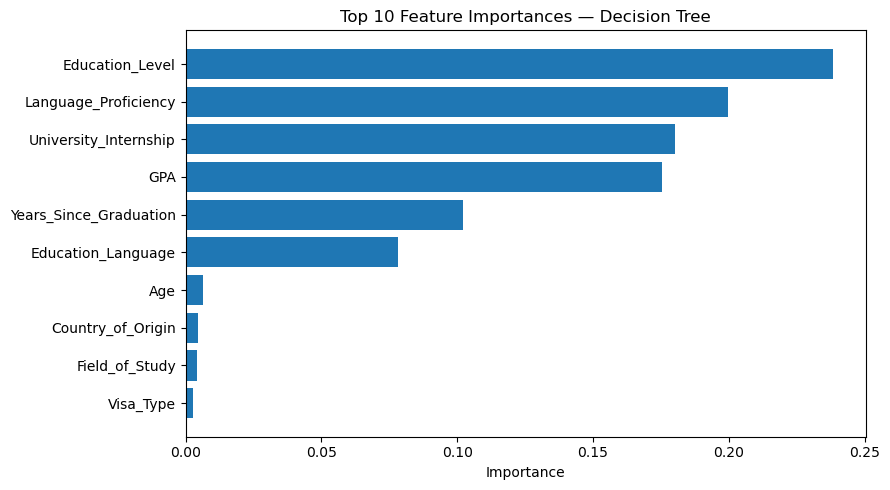

In [40]:
# Group encoded columns correctly by the original feature name
original_features = numerical_features + categorical_features

grouped_importance = []

for original in original_features:
    total = sum(
        importance
        for feature, importance in zip(
            feature_names,
            best_dt.feature_importances_
        )
        if (
            feature == f"num__{original}"
            or feature.startswith(f"cat__{original}_")
        )
    )
    grouped_importance.append({
        "Feature": original,
        "Importance": total
    })

grouped_importance_df = (
    pd.DataFrame(grouped_importance)
    .sort_values("Importance", ascending=False)
)

display(grouped_importance_df.round(4))

plt.figure(figsize=(9, 5))
plot_data = grouped_importance_df.head(10).sort_values("Importance", ascending=True)
plt.barh(plot_data["Feature"], plot_data["Importance"])
plt.title("Top 10 Feature Importances — Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 22. Permutation Importance

Permutation importance checks how much the validation Macro F1 changes when one original feature is randomly shuffled.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Use the full, original-feature pipeline for a clean feature-level view
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_dt)
])

perm_result = permutation_importance(
    dt_pipeline,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
}).sort_values("Importance_Mean", ascending=False)

display(permutation_df.round(4))

,Feature,Importance_Mean,Importance_STD
1,Education_Level,0.1194,0.0028
3,Language_Proficiency,0.0808,0.0020
10,GPA,0.0624,0.0016
14,University_Internship,0.0610,0.0025
9,Years_Since_Graduation,0.0452,0.0007
12,Education_Language,0.0284,0.0008
0,Country_of_Origin,0.0006,0.0012
13,Education_Internship,0.0006,0.0002
4,Visa_Type,0.0004,0.0006
7,Region_of_Study,0.0003,0.0003


# 23. Final Classification Summary

The task predicts `Employed`, `Continuing Education`, and `Unemployed`.

The final model is selected from the **validation results** using Macro F1, then evaluated once on the Test set.

The current results show useful predictive signal, but `Continuing Education` remains the hardest class to identify. The strongest signals are mainly education level, language proficiency, GPA, years since graduation, and selected interaction features.

**Method note:** model selection should never be based on the Test set. The cleaned notebook follows this rule.

In [43]:
# Display all duplicated rows including all columns
duplicated_rows = df[df.duplicated(keep=False)]

print("Number of duplicated rows:", len(duplicated_rows))

display(
    duplicated_rows.sort_values(
        by=df.columns.tolist()
    )
)

Number of duplicated rows: 0


,Country_of_Origin,Education_Level,Field_of_Study,Language_Proficiency,Visa_Type,Gender,University_Ranking,Region_of_Study,Age,Years_Since_Graduation,GPA,Internship_Experience,Employment_Status,Salary,Job_Sector,Education_Language,Education_Internship,University_Internship
